In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("⚠️ XGBoost not installed. Will skip XGBoost models.")

# Utilities
import json
import pickle
import os
from datetime import datetime

print("✅ All imports loaded successfully!")
print(f"XGBoost available: {XGB_AVAILABLE}")

✅ All imports loaded successfully!
XGBoost available: True


In [3]:
# LOAD FEATURE-ENGINEERED DATA
try:
    print("\n" + "="*60)
    print("LOADING FEATURE-ENGINEERED DATASET")
    print("="*60)
    
    # Load the final dataset from previous step
    final_dataset = pd.read_csv('../data/features/final_selected_dataset.csv')
    
    print(f"✅ Dataset loaded successfully!")
    print(f"Shape: {final_dataset.shape}")
    print(f"Columns: {final_dataset.columns.tolist()[:10]}...")
    print(f"Years: {final_dataset['Year'].unique()}")
    print(f"Categories: {final_dataset['Category'].nunique()}")
    
except FileNotFoundError:
    print("❌ ERROR: 'final_selected_dataset.csv' not found.")
    print("Please run the feature engineering and selection step first.")
    raise
except Exception as e:
    print(f"❌ ERROR loading dataset: {str(e)}")
    raise


LOADING FEATURE-ENGINEERED DATASET
✅ Dataset loaded successfully!
Shape: (288, 43)
Columns: ['Year', 'Category', 'Spending_Lowest_20', 'Spending_Middle_20', 'Winter_Heating_Dependency', 'Crude_Lag1', 'Crude_Volatility', 'Time_Trend', 'Ukraine_War', 'Spending_Highest_20']...
Years: [2020 2021 2022 2023 2024 2025]
Categories: 48


In [4]:
try:
    print("\n" + "="*60)
    print("DEFINING TARGETS AND FEATURES")
    print("="*60)
    
    # Target variables
    target_cols = ['Spending_Lowest_20', 'Spending_Middle_20']
    
    # Feature columns (exclude Year, Category, and targets)
    exclude_cols = ['Year', 'Category'] + target_cols
    feature_cols = [col for col in final_dataset.columns if col not in exclude_cols]
    
    print(f"Target columns: {target_cols}")
    print(f"Number of features: {len(feature_cols)}")
    print(f"Sample features: {feature_cols[:10]}")
    
    # Separate features by type for preprocessing
    numeric_features = [col for col in feature_cols if 'Lag' not in col and 
                       'Interaction' not in col and col not in ['Category'] and
                       not col.startswith('Oil_Cat_')]
    
    lag_features = [col for col in feature_cols if 'Lag' in col]
    
    interaction_features = [col for col in feature_cols if 'Interaction' in col or 
                           col.startswith('Oil_Cat_')]
    
    print(f"\nFeature categorization:")
    print(f"  - Numeric features: {len(numeric_features)}")
    print(f"  - Lag features: {len(lag_features)}")
    print(f"  - Interaction features: {len(interaction_features)}")
    
except Exception as e:
    print(f"❌ ERROR in feature definition: {str(e)}")
    raise


DEFINING TARGETS AND FEATURES
Target columns: ['Spending_Lowest_20', 'Spending_Middle_20']
Number of features: 39
Sample features: ['Winter_Heating_Dependency', 'Crude_Lag1', 'Crude_Volatility', 'Time_Trend', 'Ukraine_War', 'Spending_Highest_20', 'Spending_Second_20_YoY', 'Diesel_Price_pence_per_litre', 'Spending_Highest_20_YoY', 'Crude_Lag2']

Feature categorization:
  - Numeric features: 28
  - Lag features: 4
  - Interaction features: 7


# DATA SPLITTING - TIME-BASED

In [ ]:
class DataSplitter:
    
    
    def __init__(self, data, target_cols, feature_cols, split_strategy='time'):
        self.data = data
        self.target_cols = target_cols
        self.feature_cols = feature_cols
        self.split_strategy = split_strategy
        self.splits = {}
        self.metadata = {}
        self.errors = {}
        
    def split_time_based(self, train_years=[2020, 2021, 2022], val_year=2023, test_year=2024):
        
        try:
            print("\n" + "="*60)
            print("TIME-BASED SPLIT")
            print("="*60)
            
            # Validate years exist
            available_years = self.data['Year'].unique()
            all_years = set(train_years + [val_year, test_year])
            missing_years = all_years - set(available_years)
            if missing_years:
                print(f"⚠️ Warning: Years {missing_years} not found in data.")
            
            train_data = self.data[self.data['Year'].isin(train_years)]
            val_data = self.data[self.data['Year'] == val_year]
            test_data = self.data[self.data['Year'] == test_year]
            
            print(f"Train: {train_years} ({len(train_data)} rows, {len(train_data)/len(self.data)*100:.1f}%)")
            print(f"Validation: {val_year} ({len(val_data)} rows, {len(val_data)/len(self.data)*100:.1f}%)")
            print(f"Test: {test_year} ({len(test_data)} rows, {len(test_data)/len(self.data)*100:.1f}%)")
            
            # Verify split coverage
            if len(train_data) == 0 or len(val_data) == 0 or len(test_data) == 0:
                raise ValueError("One or more splits are empty. Check year values.")
            
            return train_data, val_data, test_data
            
        except Exception as e:
            error_msg = f"Error in time-based split: {str(e)}"
            print(f"❌ {error_msg}")
            self.errors['split_time_based'] = error_msg
            raise
    
    def split_random(self, train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):
       
        try:
            print("\n" + "="*60)
            print("RANDOM SPLIT")
            print("="*60)
            
            # Check if stratification is possible
            stratify_col = None
            if 'Category_Type' in self.data.columns:
                stratify_col = self.data['Category_Type']
                print("Using stratification by Category_Type")
            
            # First split: train vs temp
            train_data, temp_data = train_test_split(
                self.data, 
                test_size=(val_size + test_size),
                random_state=random_state,
                stratify=stratify_col
            )
            
            # Second split: val vs test
            val_data, test_data = train_test_split(
                temp_data,
                test_size=(test_size / (val_size + test_size)),
                random_state=random_state,
                stratify=temp_data['Category_Type'] if stratify_col is not None else None
            )
            
            print(f"Train: {len(train_data)} rows ({len(train_data)/len(self.data)*100:.1f}%)")
            print(f"Validation: {len(val_data)} rows ({len(val_data)/len(self.data)*100:.1f}%)")
            print(f"Test: {len(test_data)} rows ({len(test_data)/len(self.data)*100:.1f}%)")
            
            return train_data, val_data, test_data
            
        except Exception as e:
            error_msg = f"Error in random split: {str(e)}"
            print(f"❌ {error_msg}")
            self.errors['split_random'] = error_msg
            # Fallback to non-stratified
            print("⚠️ Falling back to non-stratified split...")
            train_data, temp_data = train_test_split(
                self.data, test_size=(val_size + test_size), random_state=random_state
            )
            val_data, test_data = train_test_split(
                temp_data, test_size=(test_size / (val_size + test_size)), 
                random_state=random_state
            )
            return train_data, val_data, test_data
    
    def create_features_targets(self, train_data, val_data, test_data):
        
        try:
            # Features
            X_train = train_data[self.feature_cols]
            X_val = val_data[self.feature_cols]
            X_test = test_data[self.feature_cols]
            
            # Targets
            y_train_low = train_data[self.target_cols[0]]
            y_train_mid = train_data[self.target_cols[1]]
            y_val_low = val_data[self.target_cols[0]]
            y_val_mid = val_data[self.target_cols[1]]
            y_test_low = test_data[self.target_cols[0]]
            y_test_mid = test_data[self.target_cols[1]]
            
            # Validate shapes
            assert len(X_train) == len(y_train_low) == len(y_train_mid)
            assert len(X_val) == len(y_val_low) == len(y_val_mid)
            assert len(X_test) == len(y_test_low) == len(y_test_mid)
            
            print(f"\n✅ Feature-target splits validated:")
            print(f"  - Train: X={X_train.shape}, y_low={y_train_low.shape}, y_mid={y_train_mid.shape}")
            print(f"  - Val: X={X_val.shape}, y_low={y_val_low.shape}, y_mid={y_val_mid.shape}")
            print(f"  - Test: X={X_test.shape}, y_low={y_test_low.shape}, y_mid={y_test_mid.shape}")
            
            return {
                'X_train': X_train, 'y_train_low': y_train_low, 'y_train_mid': y_train_mid,
                'X_val': X_val, 'y_val_low': y_val_low, 'y_val_mid': y_val_mid,
                'X_test': X_test, 'y_test_low': y_test_low, 'y_test_mid': y_test_mid
            }
            
        except Exception as e:
            error_msg = f"Error creating features/targets: {str(e)}"
            print(f"❌ {error_msg}")
            self.errors['create_features_targets'] = error_msg
            raise
    
    def run_split(self):
        
        try:
            if self.split_strategy == 'time':
                train_data, val_data, test_data = self.split_time_based()
            elif self.split_strategy == 'random':
                train_data, val_data, test_data = self.split_random()
            else:
                raise ValueError(f"Unknown split strategy: {self.split_strategy}")
            
            # Store metadata
            self.metadata = {
                'split_strategy': self.split_strategy,
                'train_shape': train_data.shape,
                'val_shape': val_data.shape,
                'test_shape': test_data.shape,
                'train_years': train_data['Year'].unique().tolist(),
                'val_years': val_data['Year'].unique().tolist(),
                'test_years': test_data['Year'].unique().tolist(),
                'train_categories': train_data['Category'].nunique(),
                'total_rows': len(self.data),
                'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S")
            }
            
            # Create feature-target splits
            splits = self.create_features_targets(train_data, val_data, test_data)
            self.splits = splits
            
            print("\n✅ Data splitting completed successfully!")
            return splits
            
        except Exception as e:
            print(f"❌ ERROR in data splitting: {str(e)}")
            raise

# Execute splitting
try:
    splitter = DataSplitter(
        data=final_dataset,
        target_cols=target_cols,
        feature_cols=feature_cols,
        split_strategy='time'  # Use 'time' or 'random'
    )
    
    splits = splitter.run_split()
    
except Exception as e:
    print(f"❌ Fatal error in data splitting: {str(e)}")
    raise


TIME-BASED SPLIT
Train: [2020, 2021, 2022] (144 rows, 50.0%)
Validation: 2023 (48 rows, 16.7%)
Test: 2024 (48 rows, 16.7%)

✅ Feature-target splits validated:
  - Train: X=(144, 39), y_low=(144,), y_mid=(144,)
  - Val: X=(48, 39), y_low=(48,), y_mid=(48,)
  - Test: X=(48, 39), y_low=(48,), y_mid=(48,)

✅ Data splitting completed successfully!


#  CREATE PREPROCESSING PIPELINE

In [ ]:
def create_preprocessor(feature_cols):
    
    try:
        print("\n" + "="*60)
        print("CREATING PREPROCESSING PIPELINE")
        print("="*60)
        
        # Identify feature types
        numeric_features = [col for col in feature_cols if 'Lag' not in col and 
                           'Interaction' not in col and col not in ['Category'] and
                           not col.startswith('Oil_Cat_')]
        
        lag_features = [col for col in feature_cols if 'Lag' in col]
        
        interaction_features = [col for col in feature_cols if 'Interaction' in col or 
                               col.startswith('Oil_Cat_')]
        
        print(f"Feature type distribution:")
        print(f"  - Numeric: {len(numeric_features)}")
        print(f"  - Lags: {len(lag_features)}")
        print(f"  - Interactions: {len(interaction_features)}")
        
        # Numeric pipeline (with robust scaling)
        numeric_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())  # Robust to outliers in economic data
        ])
        
        # Lag features (impute only, no scaling)
        lag_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ])
        
        # Interaction features (scaled)
        interaction_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ])
        
        # Column transformer
        preprocessor = ColumnTransformer([
            ('numeric', numeric_pipeline, numeric_features),
            ('lag', lag_pipeline, lag_features),
            ('interaction', interaction_pipeline, interaction_features)
        ], remainder='passthrough')
        
        print("\n✅ Preprocessor created successfully!")
        return preprocessor
        
    except Exception as e:
        print(f"❌ ERROR creating preprocessor: {str(e)}")
        raise

# Create preprocessor
try:
    preprocessor = create_preprocessor(feature_cols)
except Exception as e:
    print(f"❌ Fatal error: {str(e)}")
    raise


CREATING PREPROCESSING PIPELINE
Feature type distribution:
  - Numeric: 28
  - Lags: 4
  - Interactions: 7

✅ Preprocessor created successfully!


# CREATE MODEL PIPELINES

In [ ]:
def create_model_pipelines(preprocessor):
    
    try:
        print("\n" + "="*60)
        print("CREATING MODEL PIPELINES")
        print("="*60)
        
        # Base models
        models = {
            'RandomForest': RandomForestRegressor(
                n_estimators=100, 
                random_state=42,
                n_jobs=-1
            ),
            'GradientBoosting': GradientBoostingRegressor(
                n_estimators=100, 
                random_state=42
            ),
            'Ridge': Ridge(alpha=1.0)
        }
        
        # Add XGBoost if available
        if XGB_AVAILABLE:
            models['XGBoost'] = XGBRegressor(
                n_estimators=100, 
                random_state=42,
                verbosity=0
            )
        
        # Create pipelines
        pipelines = {}
        for name, model in models.items():
            pipelines[name] = Pipeline([
                ('preprocessor', preprocessor),
                ('model', model)
            ])
            print(f"  ✅ {name} pipeline created")
        
        print(f"\n✅ Created {len(pipelines)} model pipelines")
        return pipelines
        
    except Exception as e:
        print(f"❌ ERROR creating model pipelines: {str(e)}")
        raise

# Create pipelines
try:
    pipelines = create_model_pipelines(preprocessor)
except Exception as e:
    print(f"❌ Fatal error: {str(e)}")
    raise


CREATING MODEL PIPELINES
  ✅ RandomForest pipeline created
  ✅ GradientBoosting pipeline created
  ✅ Ridge pipeline created
  ✅ XGBoost pipeline created

✅ Created 4 model pipelines


# TRAIN AND EVALUATE MODELS

In [8]:
def evaluate_model(y_true, y_pred, model_name, target_name):
    
    try:
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        # MAPE (Mean Absolute Percentage Error)
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        
        print(f"\n📊 {model_name} - {target_name}:")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAE: {mae:.4f}")
        print(f"  R²: {r2:.4f}")
        print(f"  MAPE: {mape:.2f}%")
        
        return {
            'model': model_name,
            'target': target_name,
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'mape': mape
        }
        
    except Exception as e:
        print(f"❌ ERROR in evaluation: {str(e)}")
        return None


def train_and_evaluate(pipelines, splits):
    
    try:
        print("\n" + "="*60)
        print("TRAINING AND EVALUATING MODELS")
        print("="*60)
        
        results = []
        trained_models = {}
        
        # Training data
        X_train = splits['X_train']
        y_train_low = splits['y_train_low']
        y_train_mid = splits['y_train_mid']
        
        # Validation data
        X_val = splits['X_val']
        y_val_low = splits['y_val_low']
        y_val_mid = splits['y_val_mid']
        
        # Test data
        X_test = splits['X_test']
        y_test_low = splits['y_test_low']
        y_test_mid = splits['y_test_mid']
        
        for model_name, pipeline in pipelines.items():
            print(f"\n{'='*50}")
            print(f"Training {model_name}...")
            print(f"{'='*50}")
            
            try:
                # Train for Lowest_20
                print(f"\n🔹 Training for Spending_Lowest_20...")
                pipeline.fit(X_train, y_train_low)
                
                # Predict and evaluate on validation
                y_pred_val_low = pipeline.predict(X_val)
                val_metrics_low = evaluate_model(
                    y_val_low, y_pred_val_low, 
                    model_name, 'Lowest_20 (Validation)'
                )
                
                # Predict and evaluate on test
                y_pred_test_low = pipeline.predict(X_test)
                test_metrics_low = evaluate_model(
                    y_test_low, y_pred_test_low, 
                    model_name, 'Lowest_20 (Test)'
                )
                
                # Train for Middle_20
                print(f"\n🔹 Training for Spending_Middle_20...")
                # Need to fit again for Middle_20 (or clone the pipeline)
                from sklearn.base import clone
                pipeline_mid = clone(pipeline)
                pipeline_mid.fit(X_train, y_train_mid)
                
                # Predict and evaluate on validation
                y_pred_val_mid = pipeline_mid.predict(X_val)
                val_metrics_mid = evaluate_model(
                    y_val_mid, y_pred_val_mid, 
                    model_name, 'Middle_20 (Validation)'
                )
                
                # Predict and evaluate on test
                y_pred_test_mid = pipeline_mid.predict(X_test)
                test_metrics_mid = evaluate_model(
                    y_test_mid, y_pred_test_mid, 
                    model_name, 'Middle_20 (Test)'
                )
                
                # Store trained models
                trained_models[f'{model_name}_low'] = pipeline
                trained_models[f'{model_name}_mid'] = pipeline_mid
                
                # Store results
                results.append(val_metrics_low)
                results.append(test_metrics_low)
                results.append(val_metrics_mid)
                results.append(test_metrics_mid)
                
            except Exception as e:
                print(f"❌ ERROR training {model_name}: {str(e)}")
                continue
        
        return results, trained_models
        
    except Exception as e:
        print(f"❌ ERROR in training/evaluation: {str(e)}")
        raise

# Train and evaluate
try:
    results, trained_models = train_and_evaluate(pipelines, splits)
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    print("\n" + "="*60)
    print("SUMMARY OF RESULTS")
    print("="*60)
    print(results_df.to_string(index=False))
    
except Exception as e:
    print(f"❌ Fatal error in training: {str(e)}")
    raise



TRAINING AND EVALUATING MODELS

Training RandomForest...

🔹 Training for Spending_Lowest_20...

📊 RandomForest - Lowest_20 (Validation):
  RMSE: 0.3319
  MAE: 0.1665
  R²: 0.9959
  MAPE: 2.73%

📊 RandomForest - Lowest_20 (Test):
  RMSE: 0.4001
  MAE: 0.1951
  R²: 0.9940
  MAPE: 3.12%

🔹 Training for Spending_Middle_20...

📊 RandomForest - Middle_20 (Validation):
  RMSE: 0.2209
  MAE: 0.1517
  R²: 0.9991
  MAPE: 2.29%

📊 RandomForest - Middle_20 (Test):
  RMSE: 0.3900
  MAE: 0.2605
  R²: 0.9973
  MAPE: 3.14%

Training GradientBoosting...

🔹 Training for Spending_Lowest_20...

📊 GradientBoosting - Lowest_20 (Validation):
  RMSE: 0.3261
  MAE: 0.1293
  R²: 0.9961
  MAPE: 2.43%

📊 GradientBoosting - Lowest_20 (Test):
  RMSE: 0.3722
  MAE: 0.1496
  R²: 0.9948
  MAPE: 2.76%

🔹 Training for Spending_Middle_20...

📊 GradientBoosting - Middle_20 (Validation):
  RMSE: 0.1944
  MAE: 0.1421
  R²: 0.9993
  MAPE: 2.28%

📊 GradientBoosting - Middle_20 (Test):
  RMSE: 0.2666
  MAE: 0.1727
  R²: 0.998

# SAVE EVERYTHING


SAVING ALL RESULTS
📁 Saving to: ../data/splits/

📁 Saving splits...
  ✅ X_train.csv ((144, 39))
  ✅ X_val.csv ((48, 39))
  ✅ X_test.csv ((48, 39))
  ✅ y_train_low.csv ((144,))
  ✅ y_val_low.csv ((48,))
  ✅ y_test_low.csv ((48,))
  ✅ y_train_mid.csv ((144,))
  ✅ y_val_mid.csv ((48,))
  ✅ y_test_mid.csv ((48,))
  ✅ train_data.csv ((144, 41))
  ✅ val_data.csv ((48, 41))
  ✅ test_data.csv ((48, 41))

📁 Saving models...
  ✅ best_model_low.pkl (Ridge, RMSE: 0.1082)
  ✅ best_model_mid.pkl (Ridge, RMSE: 0.2258)
  ✅ model_RandomForest_low.pkl
  ✅ model_RandomForest_mid.pkl
  ✅ model_GradientBoosting_low.pkl
  ✅ model_GradientBoosting_mid.pkl
  ✅ model_Ridge_low.pkl
  ✅ model_Ridge_mid.pkl
  ✅ model_XGBoost_low.pkl
  ✅ model_XGBoost_mid.pkl
  ✅ preprocessor.pkl

📁 Saving reports...
  ✅ split_metadata.json
  ✅ model_results.json
  ✅ model_results.csv
  ✅ model_comparison.csv
  ✅ best_models.json
  ✅ feature_names.json

📁 Generating visualizations...


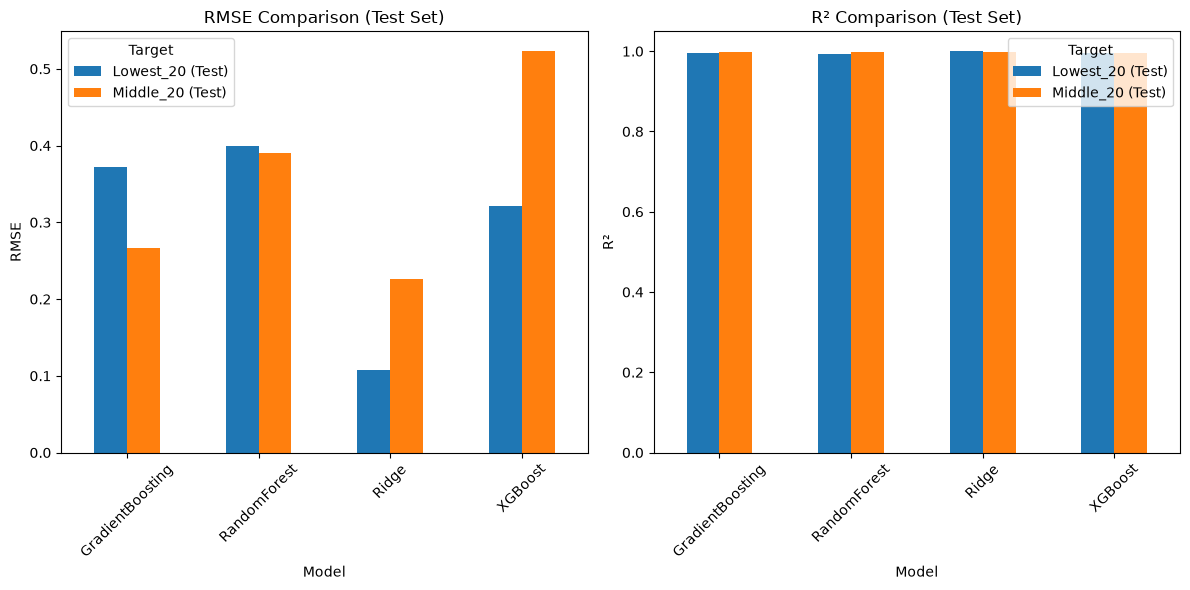

  ✅ model_comparison_plots.png

✅ All results saved successfully!
📂 All files saved in: ../data/splits/


In [9]:
def save_all_results(splits, trained_models, results_df, splitter, preprocessor, 
                     feature_cols, target_cols, save_dir='../data/splits'):
   
    try:
        print("\n" + "="*60)
        print("SAVING ALL RESULTS")
        print("="*60)
        
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        
        # Create directories
        splits_dir = f'{save_dir}/splits'
        models_dir = f'{save_dir}/models'
        reports_dir = f'{save_dir}/reports'
        
        os.makedirs(splits_dir, exist_ok=True)
        os.makedirs(models_dir, exist_ok=True)
        os.makedirs(reports_dir, exist_ok=True)
        
        print(f"📁 Saving to: {save_dir}/")
        
        
        # SAVE SPLITS
        
        print("\n📁 Saving splits...")
        
        # X splits
        for name in ['train', 'val', 'test']:
            X_data = splits[f'X_{name}']
            X_data.to_csv(f'{splits_dir}/X_{name}.csv', index=False)
            print(f"  ✅ X_{name}.csv ({X_data.shape})")
        
        # y splits for both targets
        for target in ['low', 'mid']:
            for name in ['train', 'val', 'test']:
                y_data = splits[f'y_{name}_{target}']
                y_data.to_csv(f'{splits_dir}/y_{name}_{target}.csv', index=False)
                print(f"  ✅ y_{name}_{target}.csv ({y_data.shape})")
        
        # Combined splits
        for name in ['train', 'val', 'test']:
            combined = pd.concat([
                splits[f'X_{name}'],
                pd.DataFrame({
                    f'Spending_Lowest_20': splits[f'y_{name}_low'],
                    f'Spending_Middle_20': splits[f'y_{name}_mid']
                })
            ], axis=1)
            combined.to_csv(f'{splits_dir}/{name}_data.csv', index=False)
            print(f"  ✅ {name}_data.csv ({combined.shape})")
        
        
        # SAVE MODELS
        
        print("\n📁 Saving models...")
        
        # Save best model for each target
        best_low = results_df[results_df['target'].str.contains('Lowest') & 
                              results_df['target'].str.contains('Test')].sort_values('rmse').iloc[0]
        best_mid = results_df[results_df['target'].str.contains('Middle') & 
                              results_df['target'].str.contains('Test')].sort_values('rmse').iloc[0]
        
        # Save best models
        model_low_key = f"{best_low['model']}_low"
        model_mid_key = f"{best_mid['model']}_mid"
        
        with open(f'{models_dir}/best_model_low.pkl', 'wb') as f:
            pickle.dump(trained_models[model_low_key], f)
        print(f"  ✅ best_model_low.pkl ({best_low['model']}, RMSE: {best_low['rmse']:.4f})")
        
        with open(f'{models_dir}/best_model_mid.pkl', 'wb') as f:
            pickle.dump(trained_models[model_mid_key], f)
        print(f"  ✅ best_model_mid.pkl ({best_mid['model']}, RMSE: {best_mid['rmse']:.4f})")
        
        # Save all trained models
        for name, model in trained_models.items():
            with open(f'{models_dir}/model_{name}.pkl', 'wb') as f:
                pickle.dump(model, f)
            print(f"  ✅ model_{name}.pkl")
        
        # Save preprocessor
        with open(f'{models_dir}/preprocessor.pkl', 'wb') as f:
            pickle.dump(preprocessor, f)
        print(f"  ✅ preprocessor.pkl")
        
        
        # SAVE REPORTS
        
        print("\n📁 Saving reports...")
        
        # Split metadata
        with open(f'{reports_dir}/split_metadata.json', 'w') as f:
            json.dump(splitter.metadata, f, indent=4, default=str)
        print(f"  ✅ split_metadata.json")
        
        # Results summary
        results_summary = results_df.to_dict(orient='records')
        with open(f'{reports_dir}/model_results.json', 'w') as f:
            json.dump(results_summary, f, indent=4, default=str)
        print(f"  ✅ model_results.json")
        
        # Save results as CSV
        results_df.to_csv(f'{reports_dir}/model_results.csv', index=False)
        print(f"  ✅ model_results.csv")
        
        # Model comparison report
        comparison = results_df[results_df['target'].str.contains('Test')].groupby('model').agg({
            'rmse': 'mean',
            'mae': 'mean',
            'r2': 'mean',
            'mape': 'mean'
        }).round(4)
        
        comparison.to_csv(f'{reports_dir}/model_comparison.csv')
        print(f"  ✅ model_comparison.csv")
        
        # Best model info
        best_models = {
            'best_low': {
                'model': best_low['model'],
                'rmse': best_low['rmse'],
                'mae': best_low['mae'],
                'r2': best_low['r2'],
                'mape': best_low['mape']
            },
            'best_mid': {
                'model': best_mid['model'],
                'rmse': best_mid['rmse'],
                'mae': best_mid['mae'],
                'r2': best_mid['r2'],
                'mape': best_mid['mape']
            },
            'timestamp': timestamp
        }
        
        with open(f'{reports_dir}/best_models.json', 'w') as f:
            json.dump(best_models, f, indent=4)
        print(f"  ✅ best_models.json")
        
        
        # SAVE FEATURE NAMES
        
        feature_dict = {
            'all_features': feature_cols,
            'target_features': target_cols,
            'feature_count': len(feature_cols),
            'timestamp': timestamp
        }
        
        with open(f'{reports_dir}/feature_names.json', 'w') as f:
            json.dump(feature_dict, f, indent=4)
        print(f"  ✅ feature_names.json")
        
        
        # GENERATE VISUALIZATIONS
        
        print("\n📁 Generating visualizations...")
        
        # Model comparison plot
        plt.figure(figsize=(12, 6))
        
        # RMSE comparison
        plt.subplot(1, 2, 1)
        test_results = results_df[results_df['target'].str.contains('Test')]
        pivot_rmse = test_results.pivot(index='model', columns='target', values='rmse')
        pivot_rmse.plot(kind='bar', ax=plt.gca())
        plt.title('RMSE Comparison (Test Set)')
        plt.xlabel('Model')
        plt.ylabel('RMSE')
        plt.legend(title='Target')
        plt.xticks(rotation=45)
        
        # R² comparison
        plt.subplot(1, 2, 2)
        pivot_r2 = test_results.pivot(index='model', columns='target', values='r2')
        pivot_r2.plot(kind='bar', ax=plt.gca())
        plt.title('R² Comparison (Test Set)')
        plt.xlabel('Model')
        plt.ylabel('R²')
        plt.legend(title='Target')
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.savefig(f'{reports_dir}/model_comparison_plots.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"  ✅ model_comparison_plots.png")
        
        
        # ERROR LOG
        
        if splitter.errors:
            print("\n📁 Saving error log...")
            with open(f'{reports_dir}/split_errors.json', 'w') as f:
                json.dump(splitter.errors, f, indent=4)
            print(f"  ✅ split_errors.json")
        
        print(f"\n✅ All results saved successfully!")
        print(f"📂 All files saved in: {save_dir}/")
        
    except Exception as e:
        print(f"❌ ERROR in saving results: {str(e)}")
        raise

# Execute saving
try:
    save_all_results(
        splits=splits,
        trained_models=trained_models,
        results_df=results_df,
        splitter=splitter,
        preprocessor=preprocessor,
        feature_cols=feature_cols,
        target_cols=target_cols,
        save_dir='../data/splits'
    )
    
except Exception as e:
    print(f"❌ Fatal error in saving: {str(e)}")
    raise

# FINAL SUMMARY

In [11]:
print("\n" + "="*60)
print("✅ DATA SPLITTING AND PIPELINE COMPLETE!")
print("="*60)

print("\n📊 FINAL SUMMARY:")
print(f"  - Dataset shape: {final_dataset.shape}")
print(f"  - Train size: {len(splits['X_train'])} rows")
print(f"  - Validation size: {len(splits['X_val'])} rows")
print(f"  - Test size: {len(splits['X_test'])} rows")
print(f"  - Features: {len(feature_cols)}")
print(f"  - Models trained: {len(trained_models)}")

# Get best models from results if available
try:
    if 'results_df' in locals() and len(results_df) > 0:
        # Get best models for test set
        test_results = results_df[results_df['target'].str.contains('Test')]
        
        if len(test_results) > 0:
            best_low = test_results[test_results['target'].str.contains('Lowest')].sort_values('rmse').iloc[0]
            best_mid = test_results[test_results['target'].str.contains('Middle')].sort_values('rmse').iloc[0]
            
            print(f"  - Best model for Lowest_20: {best_low['model']} (RMSE: {best_low['rmse']:.4f})")
            print(f"  - Best model for Middle_20: {best_mid['model']} (RMSE: {best_mid['rmse']:.4f})")
        else:
            print("  - ⚠️ No test results found for best model selection")
    else:
        print("  - ⚠️ Results DataFrame not available")
        
except Exception as e:
    print(f"  - ⚠️ Could not determine best models: {str(e)}")


✅ DATA SPLITTING AND PIPELINE COMPLETE!

📊 FINAL SUMMARY:
  - Dataset shape: (288, 43)
  - Train size: 144 rows
  - Validation size: 48 rows
  - Test size: 48 rows
  - Features: 39
  - Models trained: 8
  - Best model for Lowest_20: Ridge (RMSE: 0.1082)
  - Best model for Middle_20: Ridge (RMSE: 0.2258)
